# Segnature Inference

In [32]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
class ResultsEvaluation:
    
    def __init__(self, file_name):
        self.evaluations_df = json.load(open(f'../results/{file_name}.json'))
        self.run_labels, self.sampling_labels, self.signature_labels = self.get_runs_sample_labels()
        self.per_run_accuracy = self.get_runs_sample_metrics('accuracy')
        self.per_run_f1_score = self.get_runs_sample_metrics('f1')
        self.per_run_mcc = self.get_runs_sample_metrics('mcc')
        
    def get_runs_sample_labels(self):
        run_labels = []
        for run in list(self.evaluations_df.keys()):
            if self.evaluations_df[run]['sampling_0.01'] != {}:
                run_labels.append(run)  

        sampling_labels = self.evaluations_df[run_labels[0]].keys()
        sampling_labels = list(sampling_labels)
        signature_labels = []
        for i in range(len(self.evaluations_df[run_labels[0]][sampling_labels[0]])):
            signature_labels.append(self.evaluations_df[run_labels[0]][sampling_labels[0]][i]['signature'])

        return run_labels, sampling_labels, signature_labels
    
    def get_runs_sample_metrics(self, metrics):
        run_labels, sampling_labels, signature_labels = self.get_runs_sample_labels() 
        per_run_accuracy = []
        for run in run_labels:
            per_sample_accuracy = []
            for sampling in sampling_labels:
                per_signature_accuracy = []
                for i in range(len(signature_labels)):
                    per_signature_accuracy.append(self.evaluations_df[run][sampling][i]['best_model_metrics'][metrics])# Save the accuracy of each signarure for one sample

                # Here we have the mean accuracy of all signatures for one sample
                per_sample_accuracy.append(per_signature_accuracy)
            # Here we have the mean accuracy of all samples for one run
            per_run_accuracy.append(per_sample_accuracy)
        return per_run_accuracy

In [49]:
def plot_all_signature_all_sampling_graph(re):
    per_run_accuracy = np.array(re.per_run_accuracy)
    mean_accuracy = np.mean(per_run_accuracy, axis=0)

    plt.figure(figsize=(20, 10))

    # Plotta la media per ogni campione (dimensione j di per_sample_accuracy)
    for j in range(len(mean_accuracy)):
        plt.plot(re.signature_labels, mean_accuracy[j], marker='o', label=re.sampling_labels[j])

    plt.legend(re.sampling_labels)
    plt.xticks(rotation=90)
    plt.ylabel('Average Accuracy')
    plt.xlabel('Signature')
    plt.title('Average Accuracy per Signature (Averaged Across Runs)')
    plt.tight_layout()
    plt.show()
    
def plot_per_run_metric(re, attr_name="per_run_accuracy", metric_name="Accuracy"):
    metric = getattr(re, attr_name)  # accede dinamicamente all'attributo (es. re.per_run_accuracy)
    
    per_run_mean_metric = []
    for i in range(len(metric)):      
        per_sample_mean = []
        for j in range(len(metric[i])):
            per_sample_mean.append(np.mean(metric[i][j]))
        per_run_mean_metric.append(per_sample_mean)
    
    per_run_mean_metric = np.array(per_run_mean_metric)
    
    means = per_run_mean_metric.mean(axis=0)
    plt.plot(re.sampling_labels, means, marker='o', label=metric_name)
    plt.xticks(rotation=90)
    plt.ylabel(metric_name)
    plt.xlabel("Sampling Level")
    plt.grid(True)
    plt.tight_layout()

    
def plot_violins(re):
    plt.figure(figsize=(20, 10))
    per_run_accuracy = np.array(re.per_run_accuracy)
    plt.xlabel('Sampling')
    plt.xticks(range(1, len(re.sampling_labels) + 1), re.sampling_labels, rotation=90)
    plt.ylabel('Accuracy')
    plt.title('Violin Plot of Accuracy Across Runs')
    plt.violinplot([per_run_accuracy[:, j, :].flatten() for j in range(len(re.sampling_labels))], showmeans=True, showmedians=True, showextrema=True)
    
def plot_boxplot_accuracy_by_sampling(def_corr_rs, def_uncorr_rs, def_light):
    data = []
    runs = {
        'correlation': def_corr_rs,
        'non_correlation': def_uncorr_rs,
        'lightgbmxt': def_light
    }

    for run_name, run_obj in runs.items():
        for samp_idx, sampling in enumerate(run_obj.sampling_labels):
            accs = run_obj.per_run_accuracy[0][samp_idx]  # solo un run per oggetto
            for acc in accs:
                data.append({
                    'sampling': sampling,
                    'balanced_accuracy': acc,
                    'run': run_name
                })

    df = pd.DataFrame(data)

    plt.figure(figsize=(14, 6))
    sns.boxplot(x='sampling', y='balanced_accuracy', hue='run', data=df)
    plt.xticks(rotation=90)
    plt.title('Balanced Accuracy per Sampling Level (per Signature)')
    plt.tight_layout()
    plt.show()
    
def get_signature_mean_per_run(re, label):
    # Ottieni la lista delle signature
    signature_labels = re.signature_labels
    sig_acc = {sig: [] for sig in signature_labels}

    for run in re.per_run_accuracy:
        for sig_idx, sig in enumerate(signature_labels):
            # Media sui livelli di sampling
            sig_bal_acc = np.mean([sampling[sig_idx] for sampling in run])
            sig_acc[sig].append(sig_bal_acc)

    return pd.DataFrame(sig_acc, index=[label])


# Plot the graphs

## Accuracy

### Signautres Count

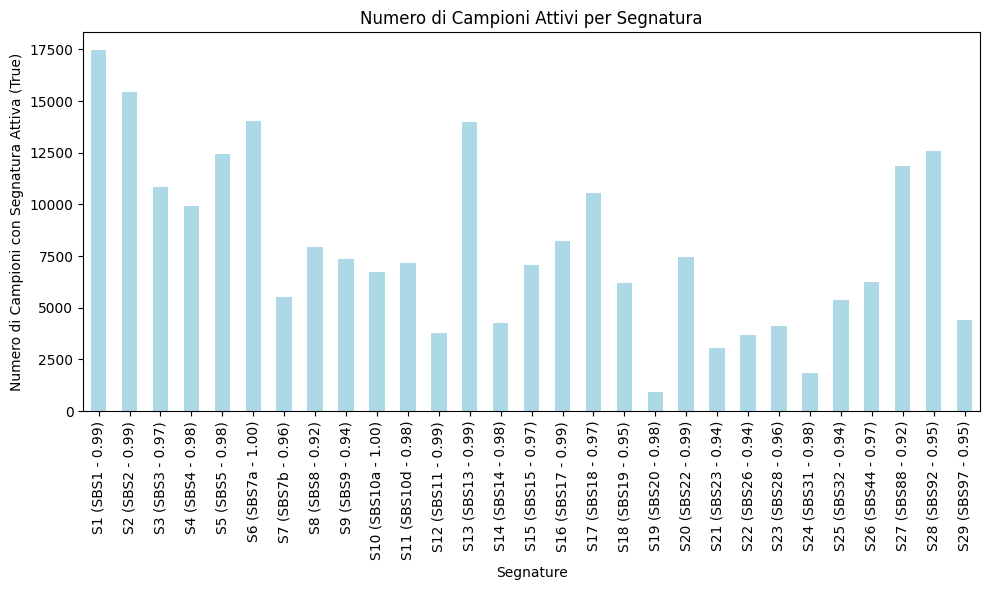

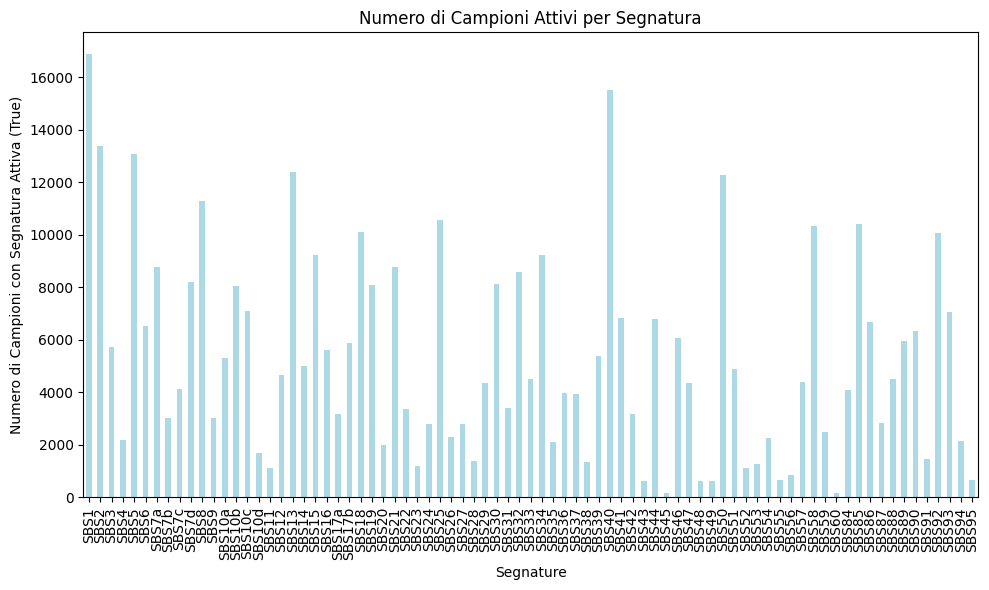

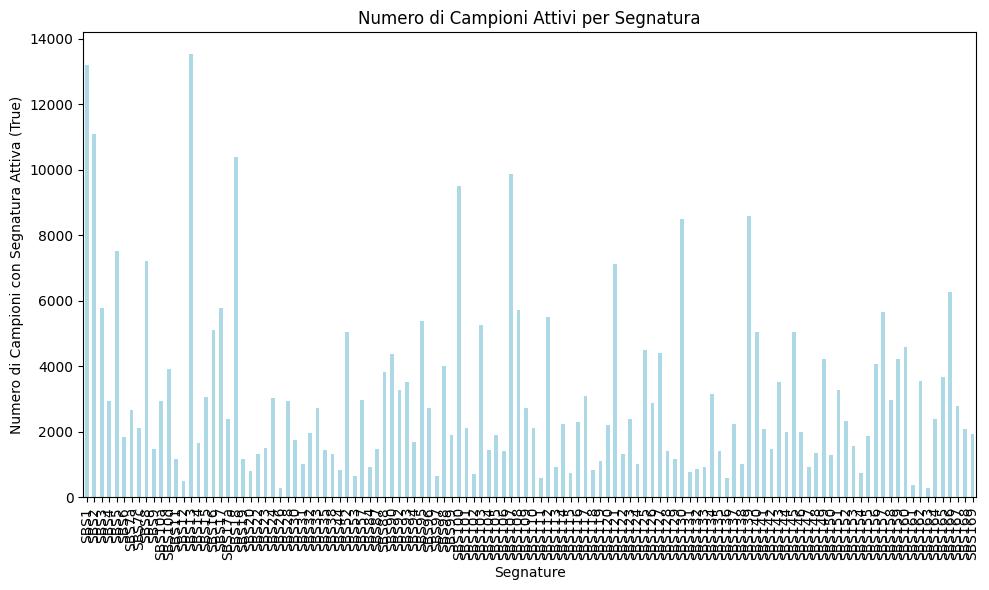

In [35]:
def number_of_sample_per_signature(folder_name):
    signature_gt_path = f'../simulations/ground_truth{folder_name}/bin_exposures.csv'

    signature_gt_df = pd.read_csv(signature_gt_path)
    signature_gt_df.head()

    active_segnature = signature_gt_df.iloc[:, 1:].sum()
    plt.figure(figsize=(10, 6))
    active_segnature.plot(kind='bar', color='lightblue')
    plt.xlabel('Segnature')
    plt.ylabel('Numero di Campioni con Segnatura Attiva (True)')
    plt.title('Numero di Campioni Attivi per Segnatura')
    plt.xticks(rotation=90)  # Ruota le etichette sull'asse X per renderle leggibili
    plt.tight_layout()
    plt.show()
    
number_of_sample_per_signature('')
number_of_sample_per_signature('_cosmic')
number_of_sample_per_signature('_reference')


### Accuracy of every Signature at the changing of the sample size

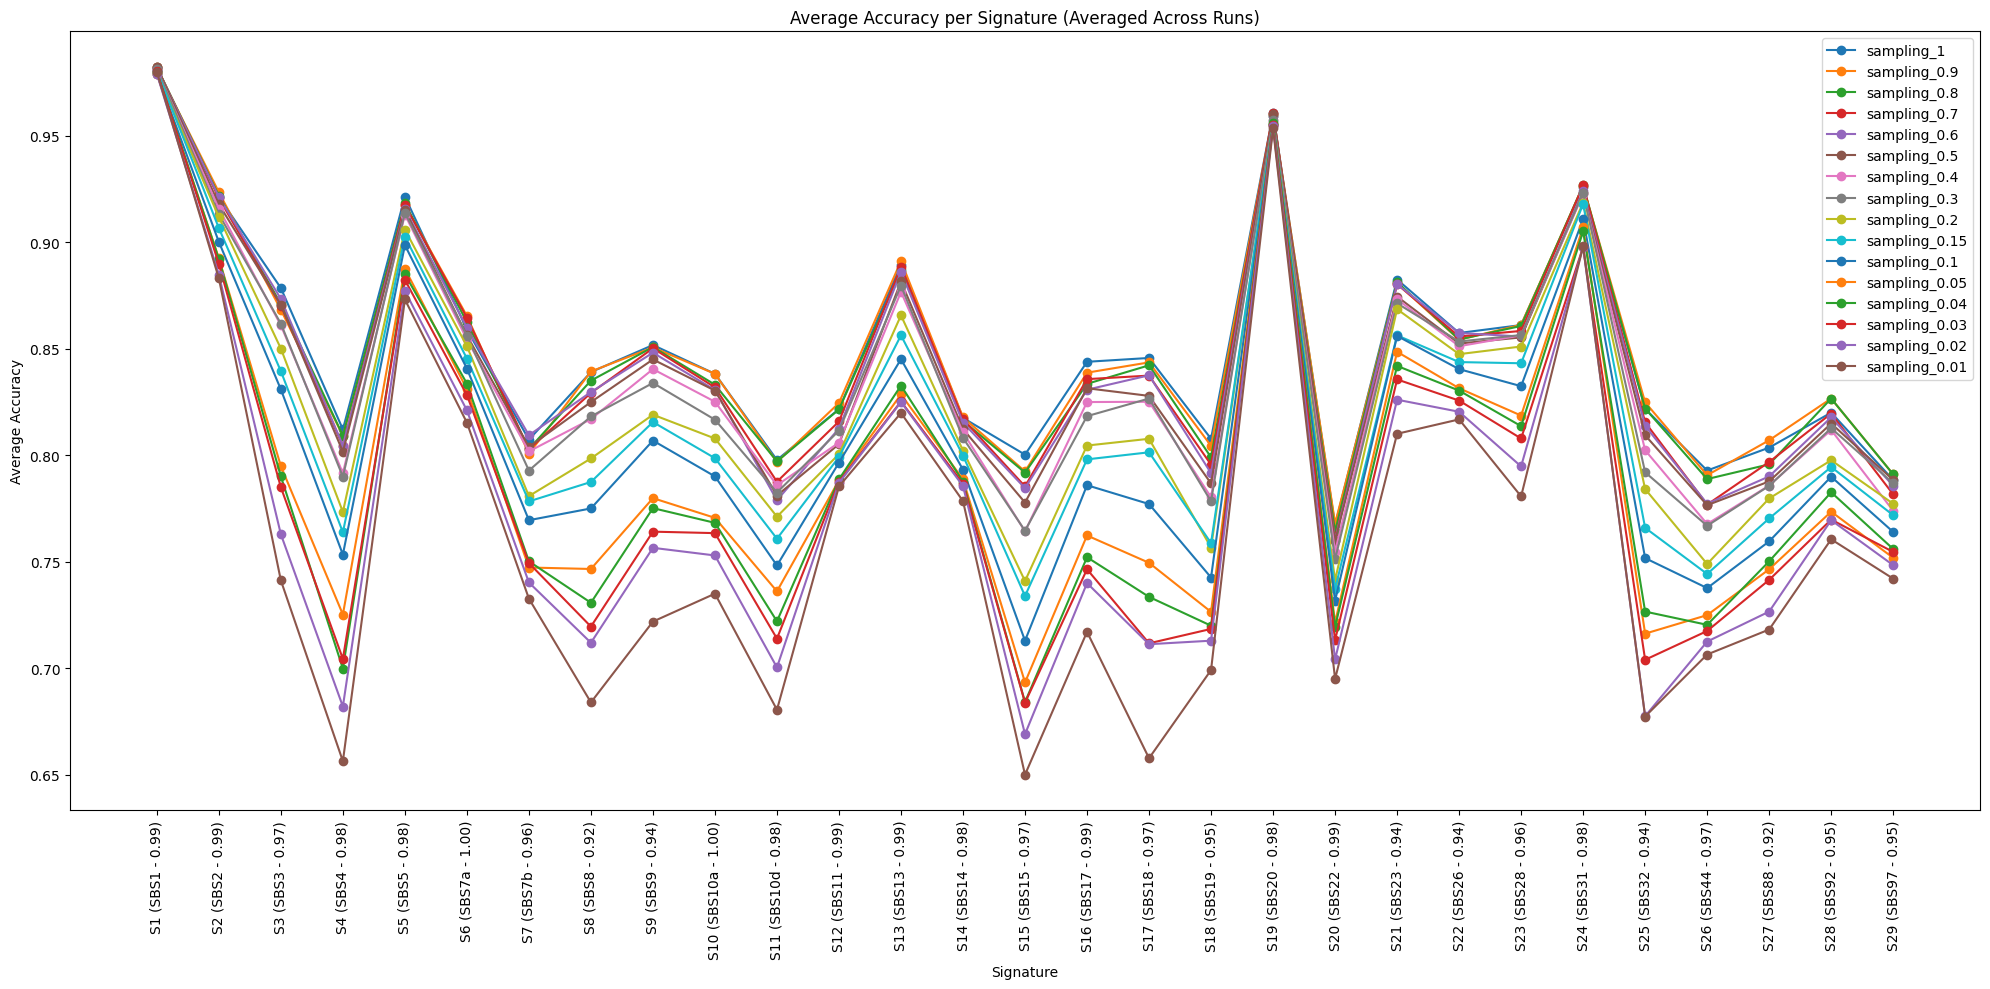

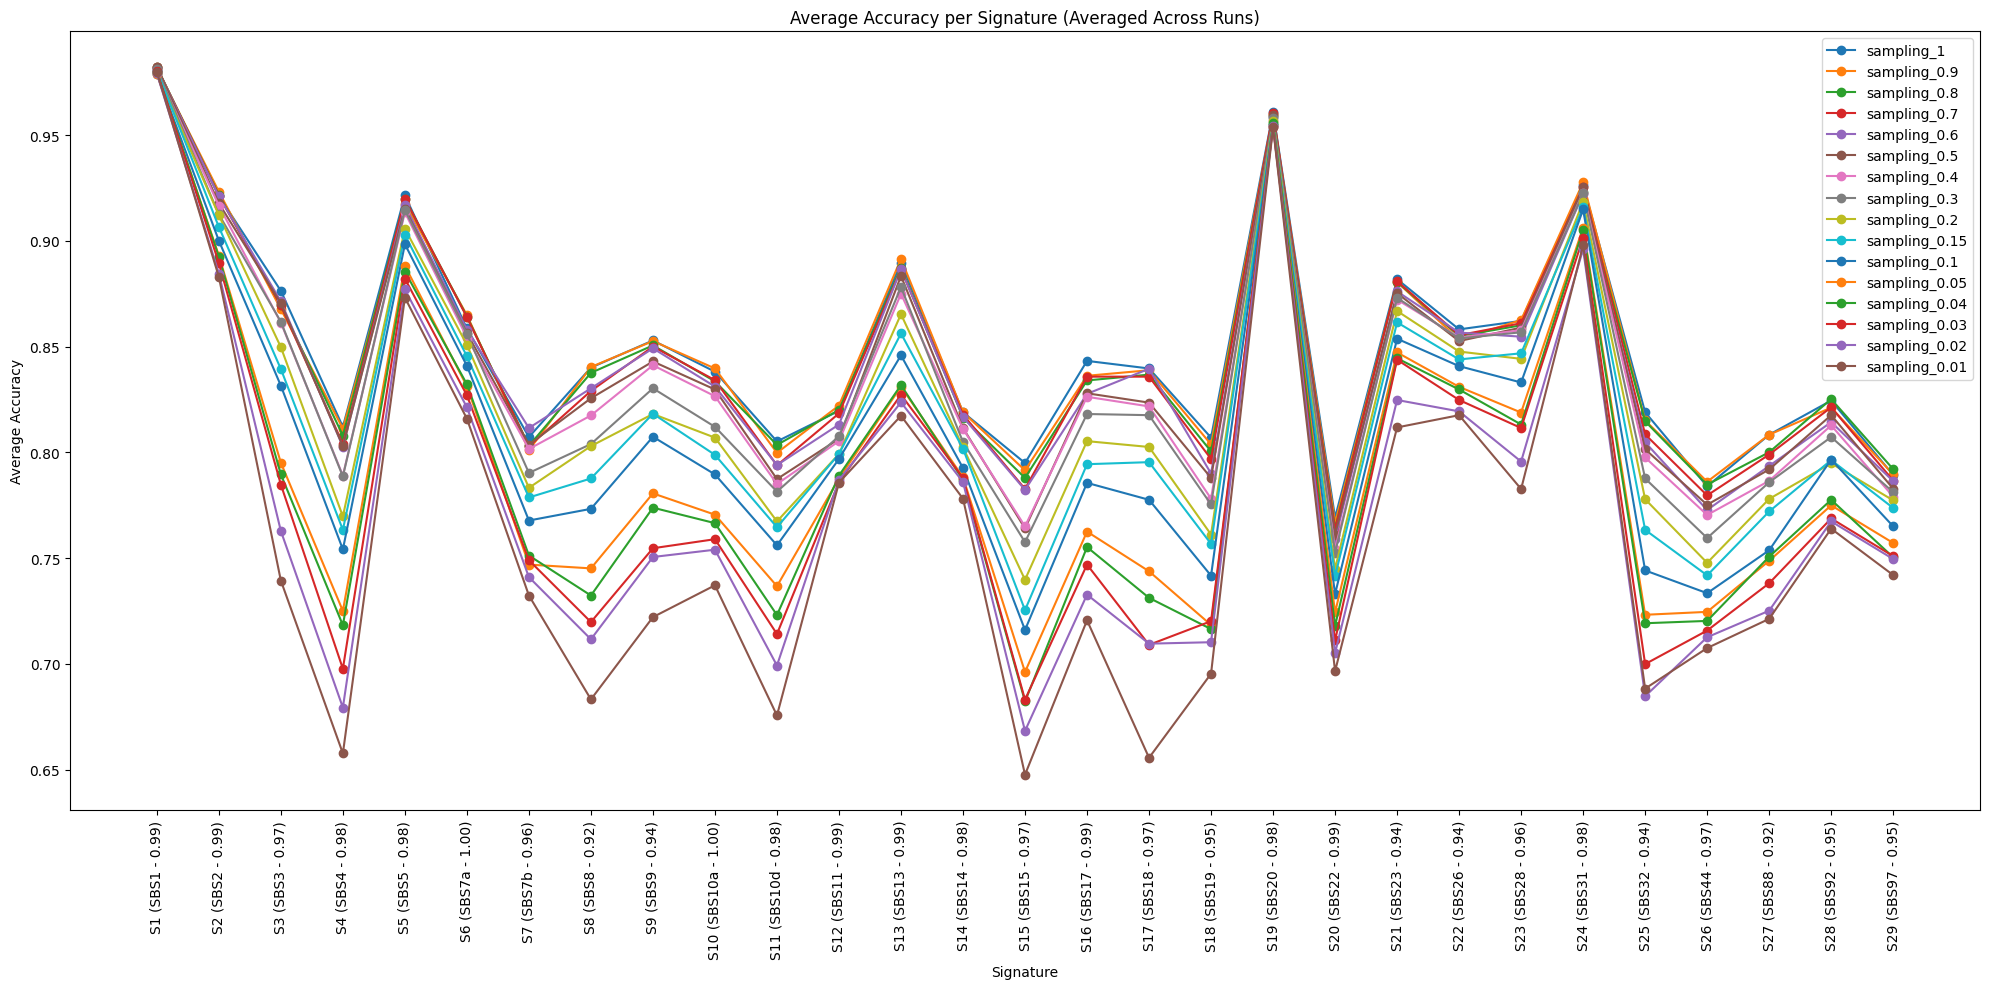

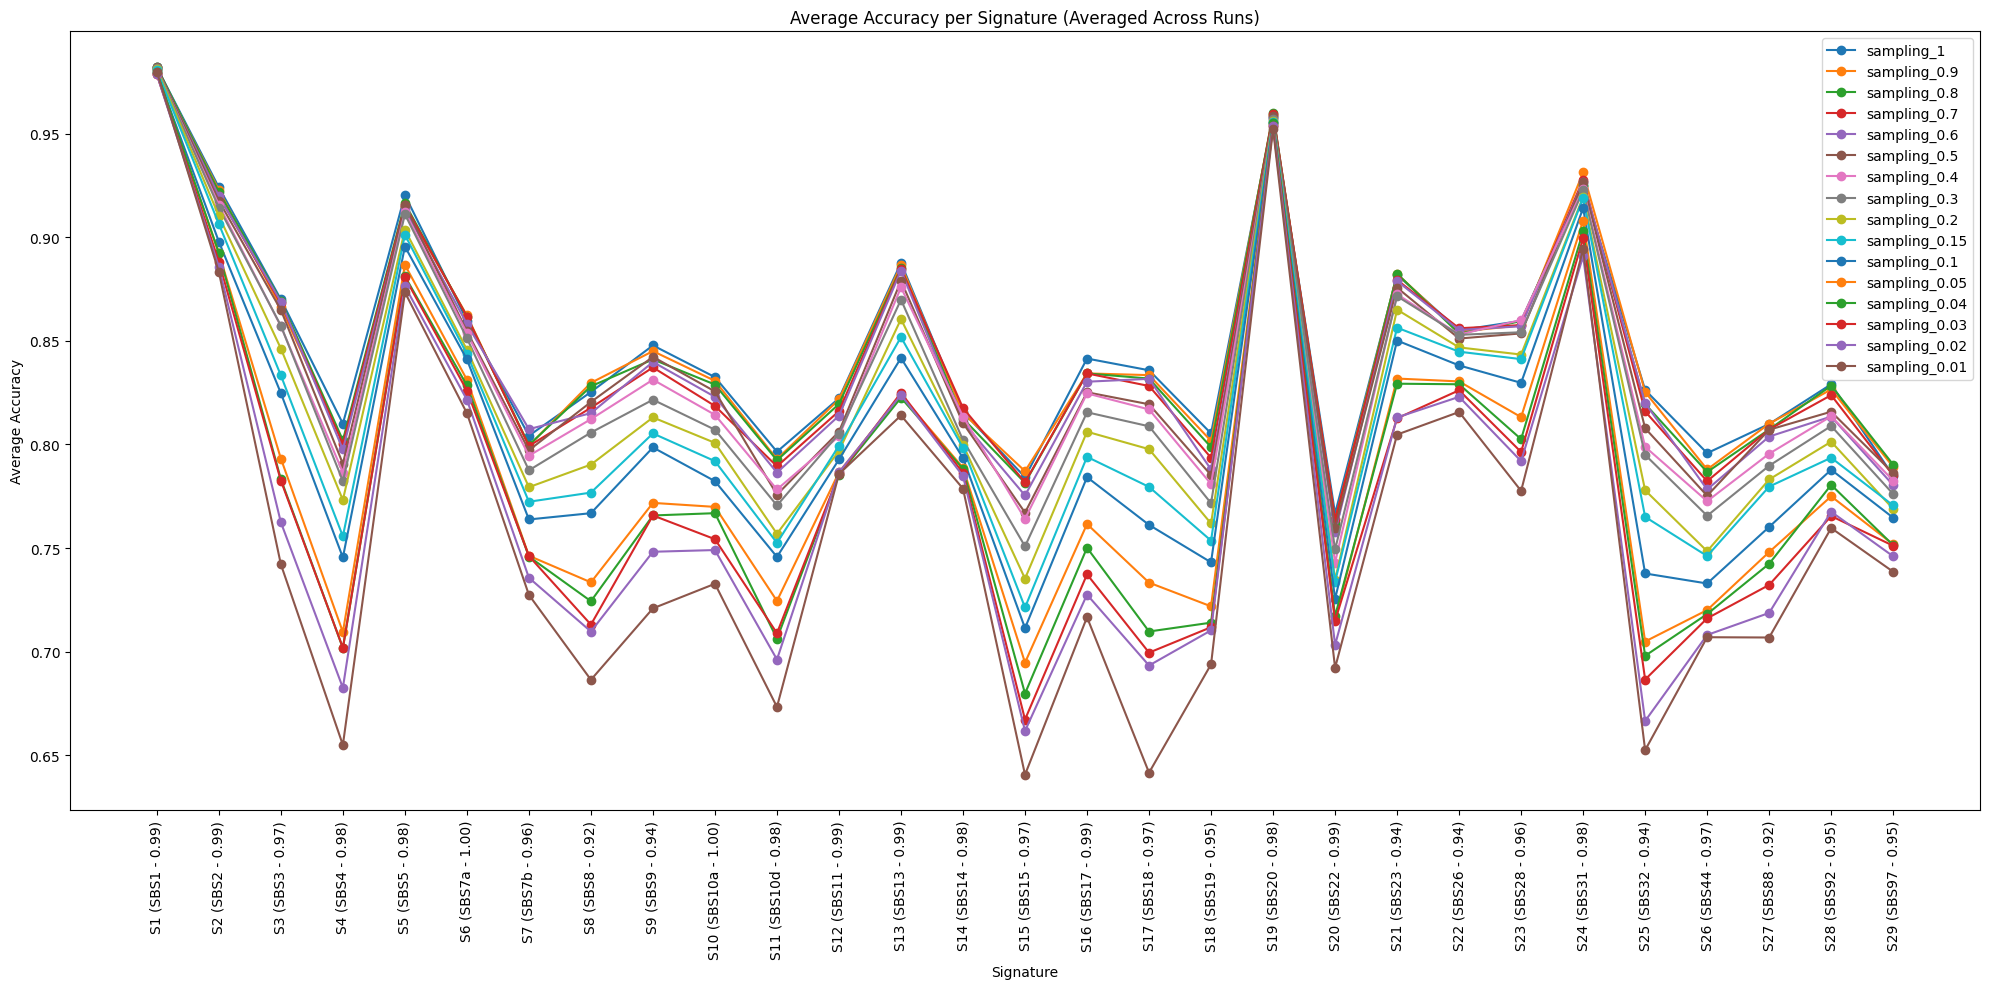

In [36]:
def_corr_rs = ResultsEvaluation('default_correlated_evaluations')
def_uncorr_rs = ResultsEvaluation('default_non_correlated_evaluations')
def_light = ResultsEvaluation('default_light_evaluations')

rss = [def_corr_rs, def_corr_rs, def_light]

plot_all_signature_all_sampling_graph(def_corr_rs)
plot_all_signature_all_sampling_graph(def_uncorr_rs)
plot_all_signature_all_sampling_graph(def_light)

### Average Accuracy per sampling size

Text(0.5, 1.0, 'Mean MCC')

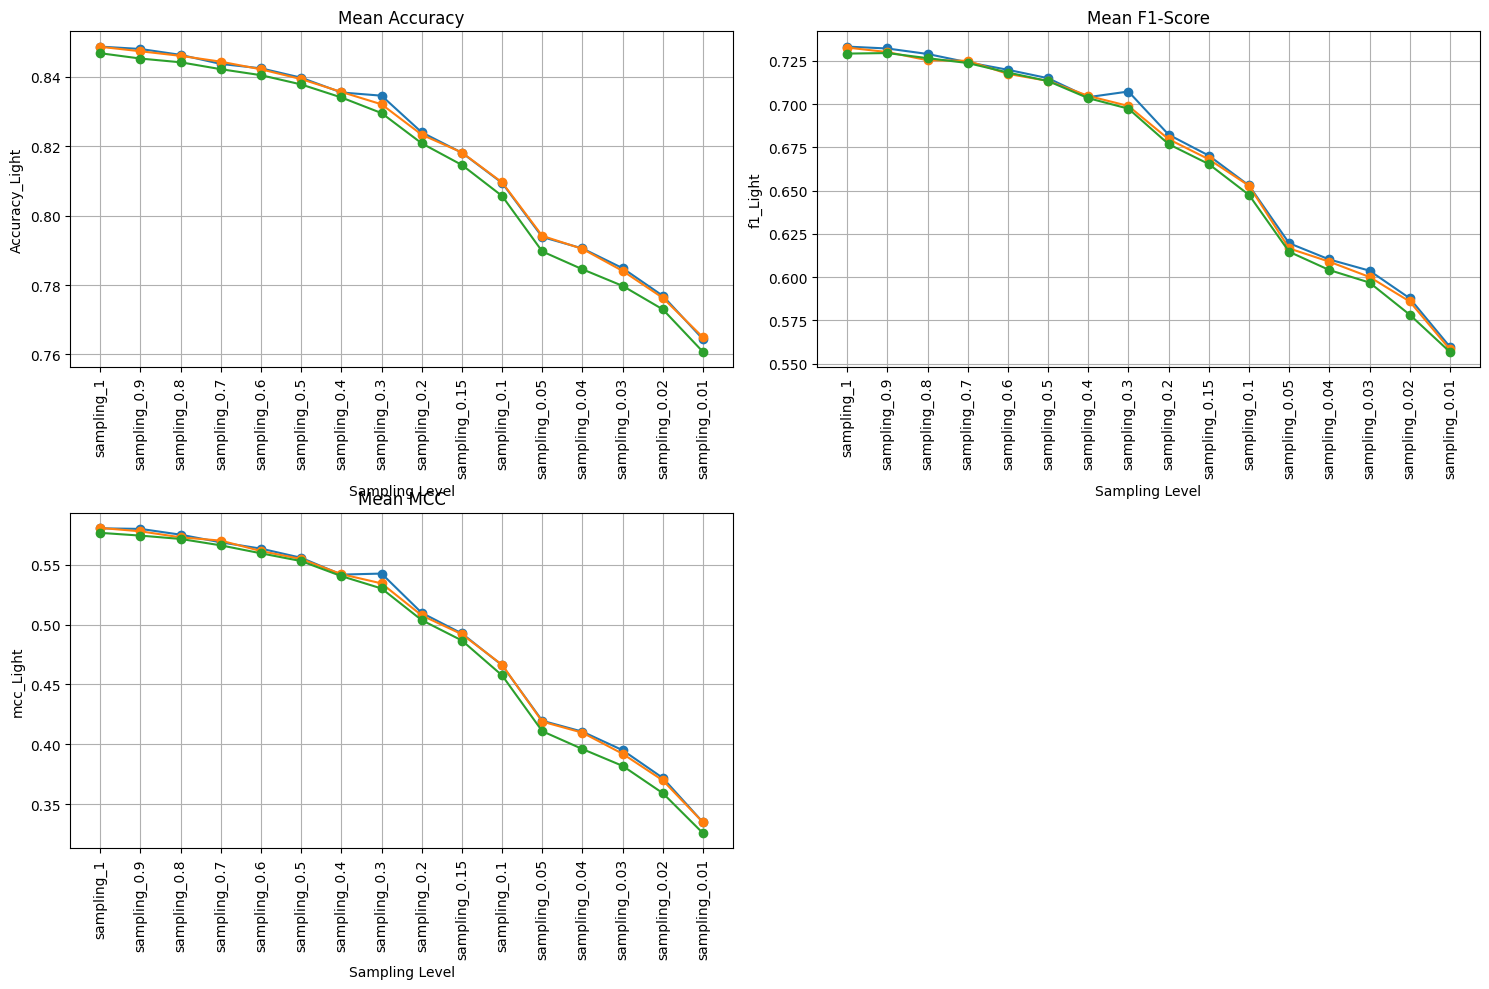

In [57]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plot_per_run_metric(def_corr_rs, attr_name='per_run_accuracy', metric_name="Accuracy_Correlated")
plot_per_run_metric(def_uncorr_rs, attr_name='per_run_accuracy', metric_name="Accuracy_Uncorrelated")
plot_per_run_metric(def_light, attr_name='per_run_accuracy', metric_name="Accuracy_Light")
plt.title('Mean Accuracy')

plt.subplot(2,2,2)
plot_per_run_metric(def_corr_rs, attr_name='per_run_f1_score', metric_name="f1_Correlated")
plot_per_run_metric(def_uncorr_rs, attr_name='per_run_f1_score', metric_name="f1_Uncorrelated")
plot_per_run_metric(def_light, attr_name='per_run_f1_score', metric_name="f1_Light")
plt.title('Mean F1-Score')

plt.subplot(2,2,3)
plot_per_run_metric(def_corr_rs, attr_name='per_run_mcc', metric_name="mcc_Correlated")
plot_per_run_metric(def_uncorr_rs, attr_name='per_run_mcc', metric_name="mcc_Uncorrelated")
plot_per_run_metric(def_light, attr_name='per_run_mcc', metric_name="mcc_Light")
plt.title('Mean MCC')

### Box-plot

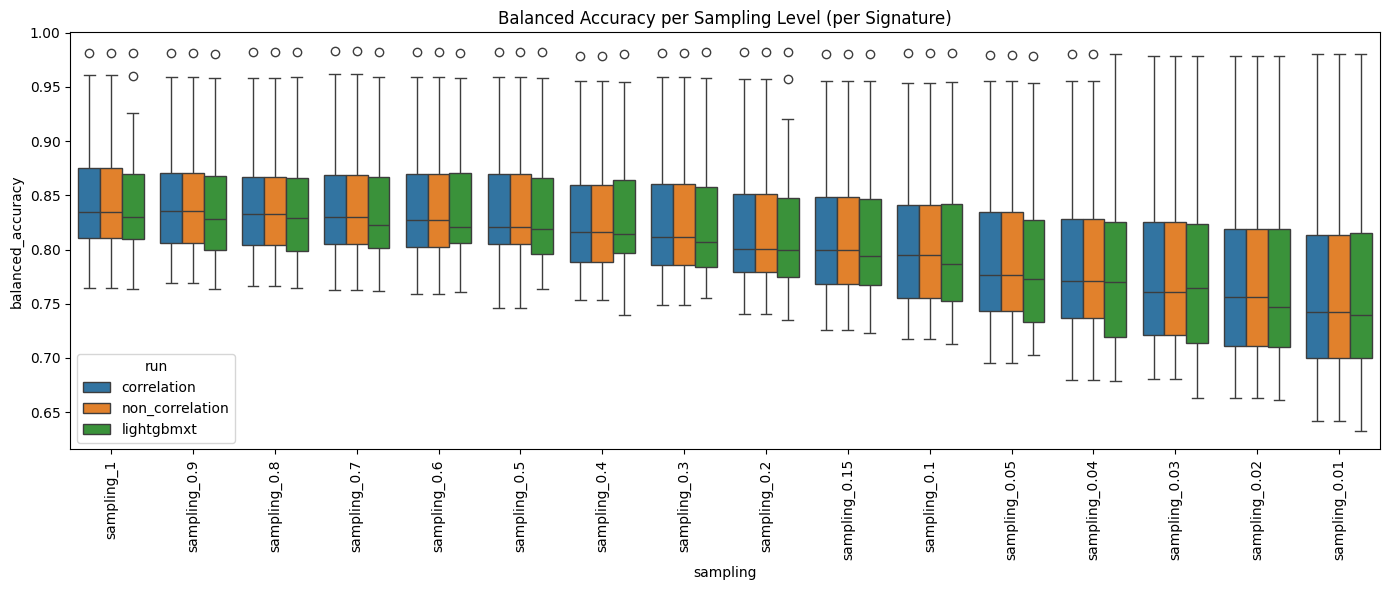

In [38]:
plot_boxplot_accuracy_by_sampling(def_uncorr_rs, def_uncorr_rs, def_light)

### Heat map of the averaged signature

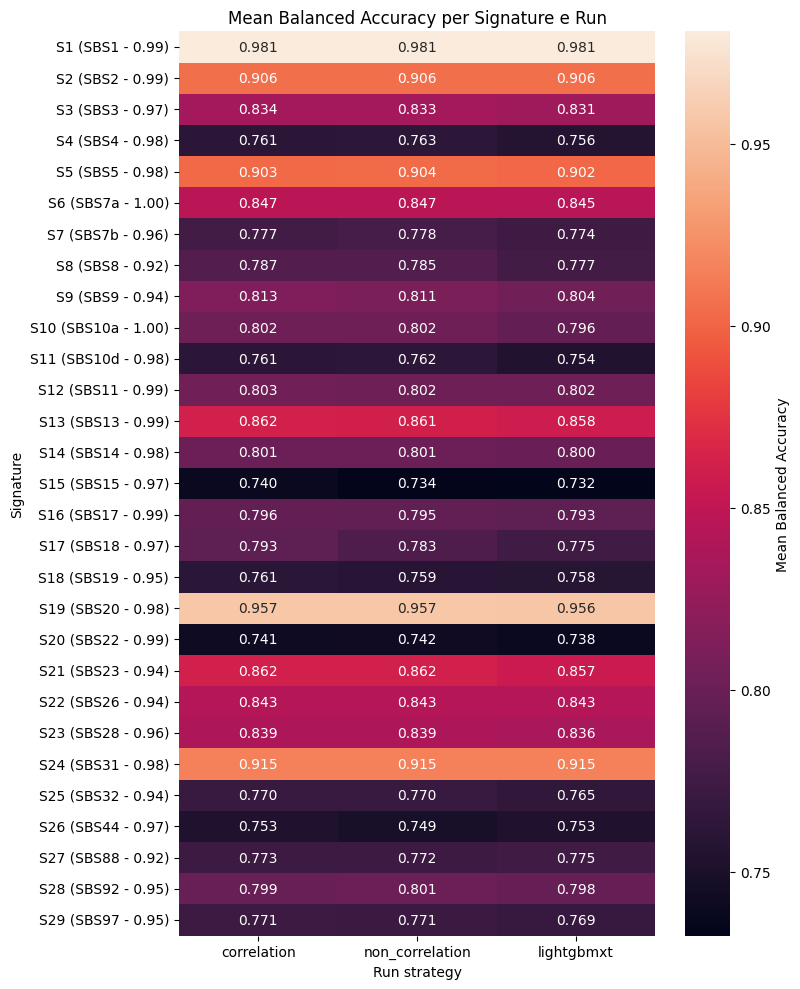

In [39]:
def plot_signature_heatmap(def_corr_rs, def_uncorr_rs, def_light):
    runs = {
        'correlation': def_corr_rs,
        'non_correlation': def_uncorr_rs,
        'lightgbmxt': def_light
    }

    # Preparo la struttura per il DataFrame
    data = { run_name: [] for run_name in runs }
    signatures = def_corr_rs.signature_labels

    for run_name, run_obj in runs.items():
        # per ogni signature, raccolgo tutte le balanced_accuracy su tutti i sampling
        for sig_idx, sig in enumerate(signatures):
            vals = []
            for samp_idx in range(len(run_obj.sampling_labels)):
                vals.append(run_obj.per_run_accuracy[0][samp_idx][sig_idx])
            data[run_name].append(np.mean(vals))

    df = pd.DataFrame(data, index=signatures)

    # Plotto la heatmap
    plt.figure(figsize=(8,10))
    sns.heatmap(df, annot=True, fmt=".3f", cbar_kws={'label': 'Mean Balanced Accuracy'})
    plt.title('Mean Balanced Accuracy per Signature e Run')
    plt.ylabel('Signature')
    plt.xlabel('Run strategy')
    plt.tight_layout()
    plt.show()
    
plot_signature_heatmap(def_corr_rs, def_uncorr_rs, def_light)

In [40]:
for metric in ["per_run_accuracy", "per_run_f1_score", "per_run_mcc"]:
    metric_array = getattr(def_corr_rs, metric)
    means = np.mean([[np.mean(sample) for sample in run] for run in metric_array], axis=0)
    print(metric, np.round(means, 3))


per_run_accuracy [0.849 0.848 0.846 0.844 0.842 0.84  0.836 0.835 0.824 0.818 0.809 0.794
 0.791 0.785 0.777 0.764]
per_run_f1_score [0.733 0.732 0.729 0.724 0.72  0.715 0.704 0.707 0.682 0.67  0.653 0.62
 0.61  0.604 0.588 0.56 ]
per_run_mcc [0.58  0.58  0.575 0.569 0.563 0.556 0.542 0.542 0.51  0.493 0.466 0.42
 0.411 0.395 0.372 0.335]


# Analysis on the best models

### Best Models

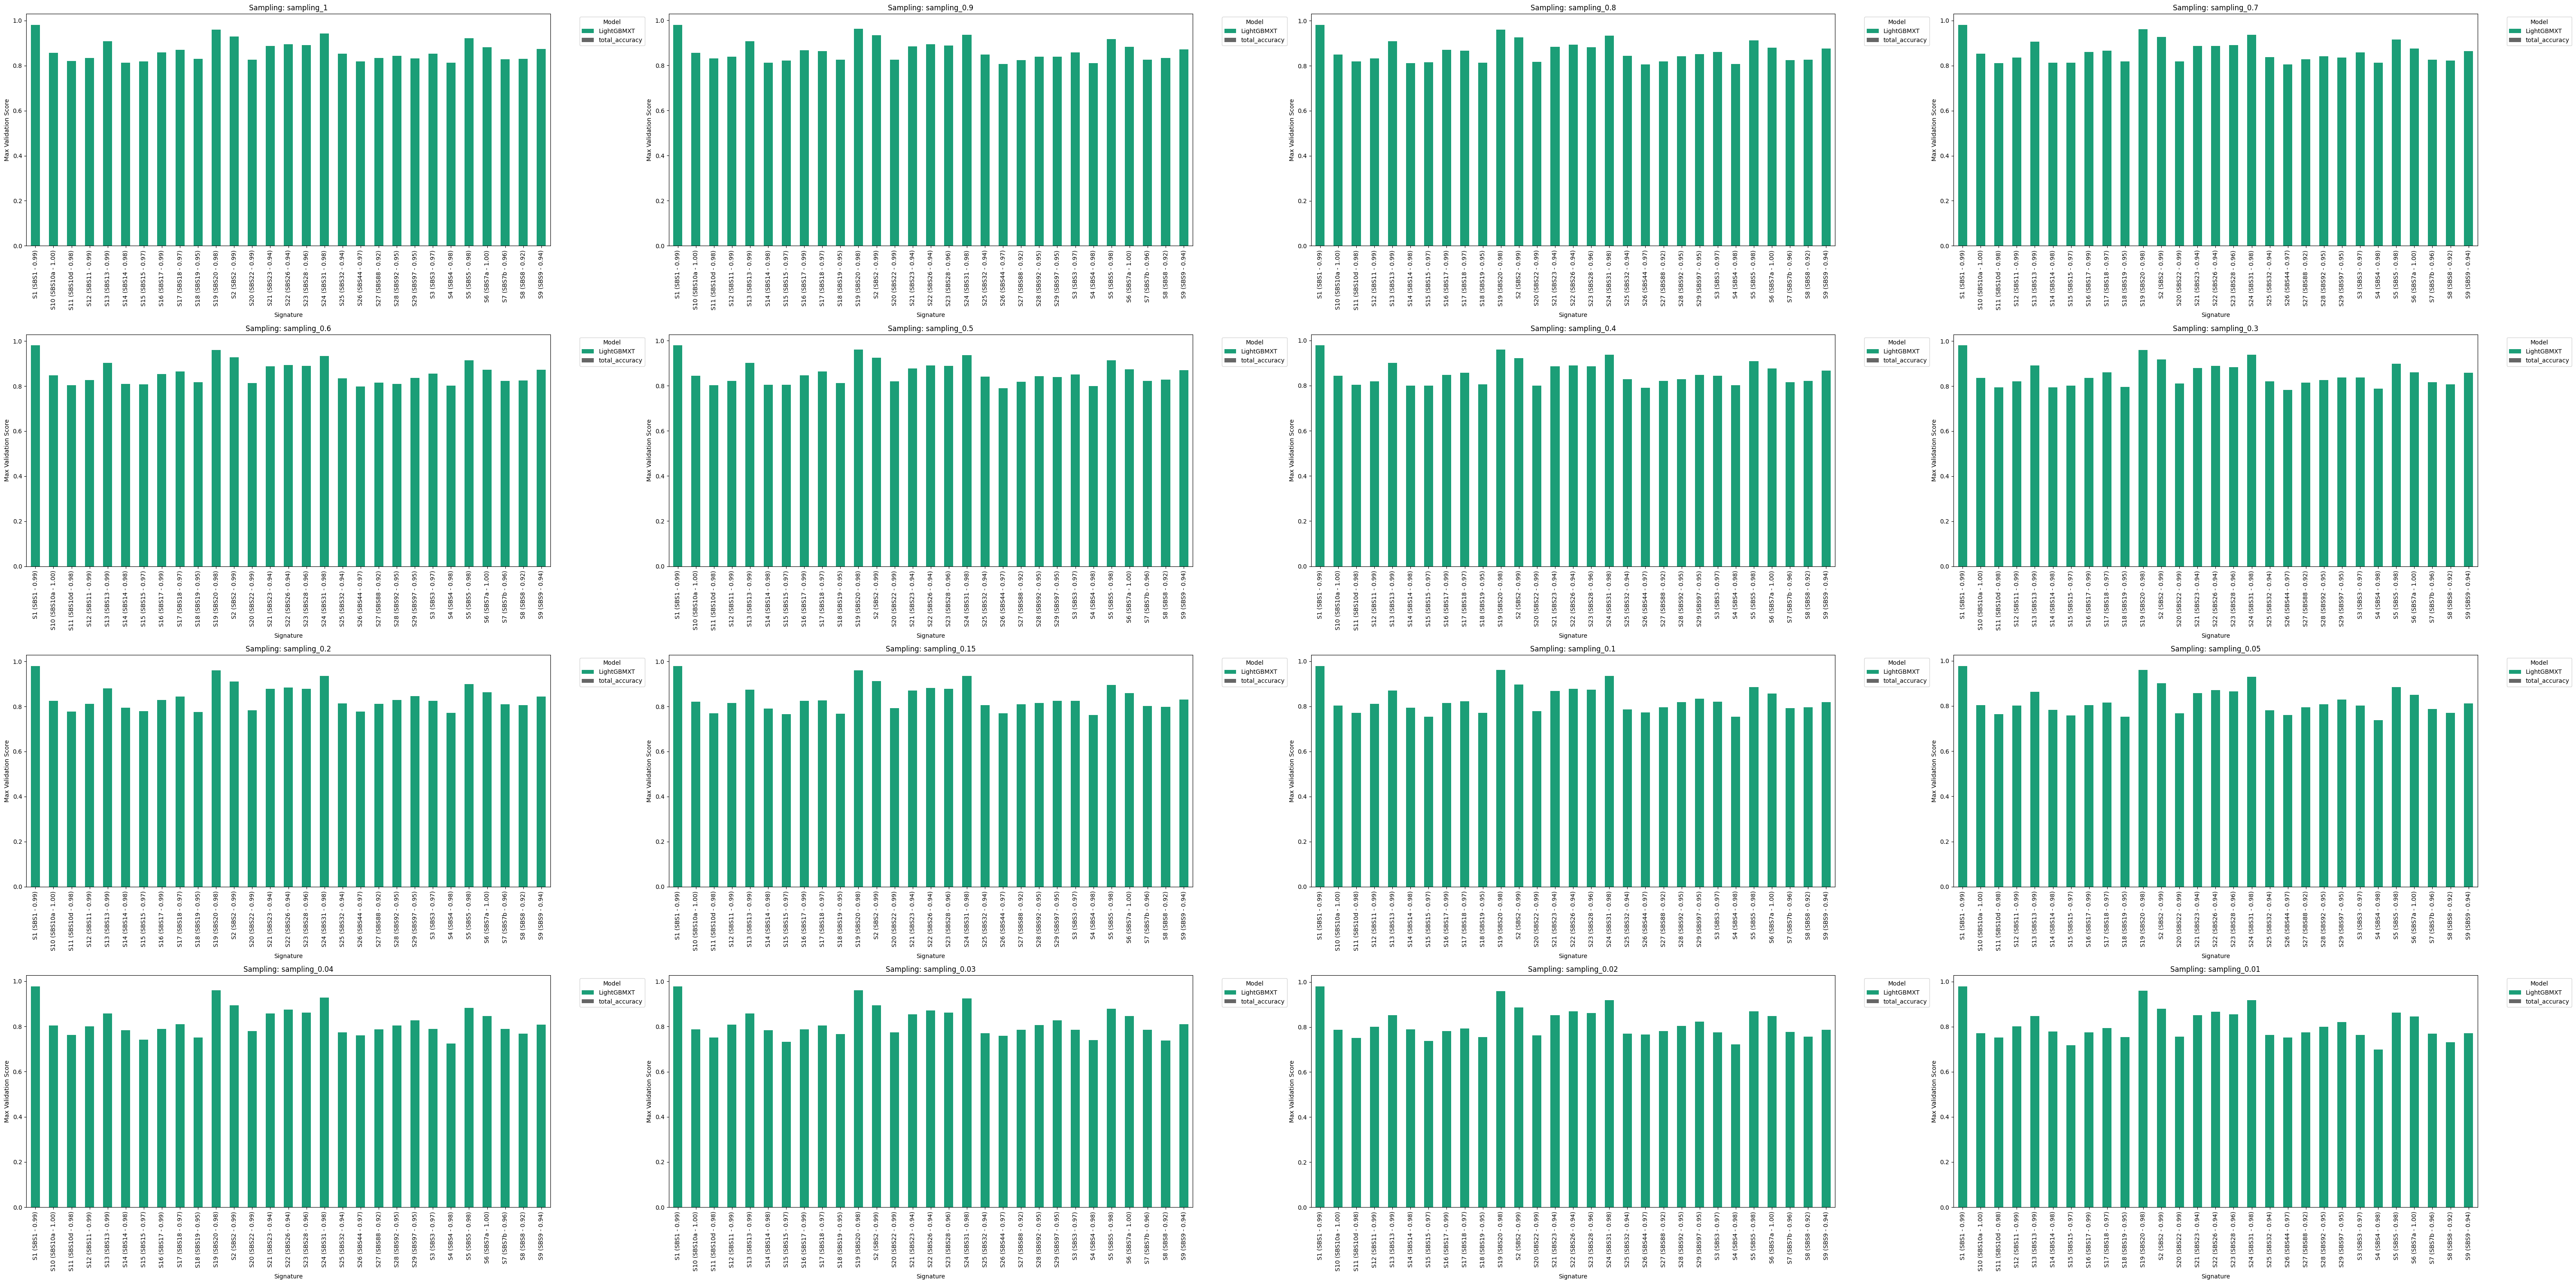

In [41]:
def plot_evaluation_ensamble(er):
    fig, axes = plt.subplots(4, 4, figsize=(60, 30))
    axes = axes.flatten()

    for plot_idx, sampling in enumerate(er.sampling_labels):
        rows = []
        for run in er.run_labels:
            for i, sig in enumerate(er.signature_labels):
                df = pd.DataFrame(er.evaluations_df[run][sampling][i]['ensemble_info'])
                for _, row in df.iterrows():
                    rows.append({
                        'signature': sig,
                        'model': row['model_name'],
                        'val_score': row['val_score']
                    })
                rows.append({
                    'signature': sig,
                    'model': 'total_accuracy',
                    'val_score': er.evaluations_df['run_1'][sampling][i]['best_model_val_score']
            })
            break  # solo il primo run

        # Genera il grafico per il subplot corrente
        df_plot = pd.DataFrame(rows)
        processed = []

        for sig, group in df_plot.groupby('signature'):
            sorted_group = group.sort_values('val_score')
            prev = 0
            for _, row in sorted_group.iterrows():
                height = row['val_score'] - prev
                processed.append({
                    'signature': sig,
                    'model': row['model'],
                    'height': height
                })
                prev = row['val_score']

        df_stacked = pd.DataFrame(processed)
        # Pivot e riordino delle colonne
        df_pivot = df_stacked.pivot_table(index='signature', columns='model', values='height', fill_value=0)
        df_pivot.plot(kind='bar', stacked=True, colormap='Dark2', ax=axes[plot_idx])
        axes[plot_idx].set_title(f"Sampling: {sampling}")
        axes[plot_idx].set_ylabel("Max Validation Score")
        axes[plot_idx].set_xlabel("Signature")
        axes[plot_idx].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.tight_layout()    
plot_evaluation_ensamble(def_light)
